In [10]:
import os
folders = [
    "data/raw",
    "data/processed",
    "data/encrypted",
    "reports"
]
for folder in folders:
    os.makedirs(folder, exist_ok=True)
print("Project folders created successfully!")

Project folders created successfully!


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from cryptography.fernet import Fernet
from faker import Faker
import random
from presidio_analyzer import AnalyzerEngine
from azure.storage.blob import BlobServiceClient
import os
import warnings
warnings.filterwarnings("ignore")
print("All libraries imported successfully!")

All libraries imported successfully!


In [12]:
transaction_df = pd.read_csv("data/1raw/train_transaction.csv")
identity_df = pd.read_csv("data/1raw/train_identity.csv")

In [13]:
df= transaction_df.merge(identity_df, how='left', on='TransactionID')
print("Dataset Shape:", df.shape)

Dataset Shape: (590540, 434)


In [14]:
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [15]:
print("Dataset Information")
print(df.info())

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), str(31)
memory usage: 1.9 GB
None


In [16]:
print("Missing Values")
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing.head(20)

Missing Values


id_24    585793
id_25    585408
id_07    585385
id_08    585385
id_21    585381
id_26    585377
id_27    585371
id_23    585371
id_22    585371
dist2    552913
D7       551623
id_18    545427
D13      528588
D14      528353
D12      525823
id_03    524216
id_04    524216
D6       517353
id_33    517251
id_10    515614
dtype: int64

In [17]:
print("Statistical Summary")
df.describe().T

Statistical Summary


,count,mean,std,min,25%,50%,75%,max
TransactionID,590540.0,3.282270e+06,1.704744e+05,2987000.000,3134634.750,3282269.500,3429904.25,3.577539e+06
isFraud,590540.0,3.499001e-02,1.837546e-01,0.000,0.000,0.000,0.00,1.000000e+00
TransactionDT,590540.0,7.372311e+06,4.617224e+06,86400.000,3027057.750,7306527.500,11246620.00,1.581113e+07
TransactionAmt,590540.0,1.350272e+02,2.391625e+02,0.251,43.321,68.769,125.00,3.193739e+04
card1,590540.0,9.898735e+03,4.901170e+03,1000.000,6019.000,9678.000,14184.00,1.839600e+04
...,...,...,...,...,...,...,...,...
id_22,5169.0,1.600271e+01,6.897665e+00,10.000,14.000,14.000,14.00,4.400000e+01
id_24,4747.0,1.280093e+01,2.372447e+00,11.000,11.000,11.000,15.00,2.600000e+01
id_25,5132.0,3.296089e+02,9.746109e+01,100.000,321.000,321.000,371.00,5.480000e+02
id_26,5163.0,1.490703e+02,3.210199e+01,100.000,119.000,149.000,169.00,2.160000e+02


In [18]:
df["isFraud"].value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

In [19]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": missing_percent
})
missing_df.sort_values("Missing %", ascending=False).head(30)

,Missing Count,Missing %
id_24,585793,99.196159
id_25,585408,99.130965
id_07,585385,99.127070
id_08,585385,99.127070
id_21,585381,99.126393
id_26,585377,99.125715
id_27,585371,99.124699
id_23,585371,99.124699
id_22,585371,99.124699
dist2,552913,93.628374


In [20]:
threshold = 90
missing_percent = (df.isnull().mean()) * 100
columns_to_drop = missing_percent[missing_percent > threshold].index
print(f"Columns to drop: {len(columns_to_drop)}")
df = df.drop(columns=columns_to_drop)
print(df.shape)

Columns to drop: 12
(590540, 422)


In [ ]:
duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


In [22]:
fake = Faker()
Faker.seed(42)
random.seed(42)

In [23]:
df["CustomerName"] = [fake.name() for _ in range(len(df))]
df["Email"] = [fake.email() for _ in range(len(df))]
df["PhoneNumber"] = [fake.phone_number() for _ in range(len(df))]
df["Address"] = [fake.address().replace("\n", ", ") for _ in range(len(df))]
df["NationalID"] = [fake.ssn() for _ in range(len(df))]

df["CreditCardNumber"] = [
    fake.credit_card_number(card_type=None)
    for _ in range(len(df))
]

In [24]:
df[
    [
        "CustomerName",
        "Email",
        "PhoneNumber",
        "Address",
        "NationalID",
        "CreditCardNumber"
    ]
].head()

,CustomerName,Email,PhoneNumber,Address,NationalID,CreditCardNumber
0,Allison Hill,thoover@example.com,275-653-0597x58878,"8714 Lane Islands Suite 049, Lake Thomas, NY 6...",332-50-4363,3527321335764609
1,Noah Rhodes,billypowers@example.com,001-677-642-4621x2502,"3542 Webster Greens Suite 575, Port Timothyche...",399-94-7696,3505503506811253
2,Angie Henderson,wrightjohnny@example.com,001-276-536-8129,"2922 Raymond Cliffs Suite 400, Bryanville, VI ...",179-27-2684,370146769909717
3,Daniel Wagner,danielsanders@example.org,(755)697-6658,"24557 Jesse Passage Apt. 731, Hendersonfurt, O...",616-22-0156,4808957127136943962
4,Cristian Santos,dmoore@example.org,363.728.3783,"796 Sheila Hollow, Moorehaven, PR 85294",741-55-4242,343920394738327


In [25]:
classification = {
    "CustomerName":"PII",
    "Email":"PII",
    "PhoneNumber":"PII",
    "Address":"PII",
    "NationalID":"PII",
    "CreditCardNumber":"Financial",
    "TransactionAmt":"Financial",
    "addr1":"Sensitive",
    "addr2":"Sensitive",
    "P_emaildomain":"Sensitive",
    "R_emaildomain":"Sensitive",
    "DeviceInfo":"Sensitive",
    "isFraud":"Target"
}

classification

{'CustomerName': 'PII',
 'Email': 'PII',
 'PhoneNumber': 'PII',
 'Address': 'PII',
 'NationalID': 'PII',
 'CreditCardNumber': 'Financial',
 'TransactionAmt': 'Financial',
 'addr1': 'Sensitive',
 'addr2': 'Sensitive',
 'P_emaildomain': 'Sensitive',
 'R_emaildomain': 'Sensitive',
 'DeviceInfo': 'Sensitive',
 'isFraud': 'Target'}

In [26]:
classification_df = pd.DataFrame(
    classification.items(),
    columns=["Column","Classification"]
)

classification_df.to_csv(
    "reports/data_classification.csv",
    index=False
)

In [27]:
pii_columns = [
    "CustomerName",
    "Email",
    "PhoneNumber",
    "Address",
    "NationalID",
    "CreditCardNumber"
]

print("PII Columns:")

for col in pii_columns:
    print(col)

PII Columns:
CustomerName
Email
PhoneNumber
Address
NationalID
CreditCardNumber


In [28]:
from cryptography.fernet import Fernet
key = Fernet.generate_key()
cipher = Fernet(key)
with open("secret.key","wb") as file:
    file.write(key)

In [29]:
def encrypt(value):
    if pd.isna(value):
        return value
    value = str(value)
    return cipher.encrypt(
        value.encode()
    ).decode()

In [30]:
encrypted_df = df.copy()
columns_to_encrypt = [
    "CustomerName",
    "Email",
    "PhoneNumber",
    "Address",
    "NationalID",
    "CreditCardNumber"
]
for col in columns_to_encrypt:
    encrypted_df[col] = encrypted_df[col].apply(encrypt)

In [31]:
encrypted_df[
    columns_to_encrypt
].head()

,CustomerName,Email,PhoneNumber,Address,NationalID,CreditCardNumber
0,gAAAAABqQAskOXUw8aXIoRiy8RFlhguJzphJWVolZZMPZE...,gAAAAABqQAt1rQHZXz3Qo6P9tuCMRFZUwYS4X03VQfS_sd...,gAAAAABqQAu1JiXq_OKtAtZlJhDgk5Ch1acEHDxCtNLpR5...,gAAAAABqQAv9tEawvZYSpCpjNYoZl7GI_bhdxRgrcnp9dh...,gAAAAABqQAxOoPsfIJMgu_UHwR5_numrYeLGIgb9h5kV27...,gAAAAABqQAzQboJVH42KAzFtJmqoKQWGZ86gvjwgckVNPW...
1,gAAAAABqQAskJUd8AuTaFgC7JNAH73tRPJigtLvMQ-Panv...,gAAAAABqQAt1Ot1OZy2eD19n91UjsE3PDkLAhj0q0OvnMD...,gAAAAABqQAu1-uvVmTqVUPdqWVXkyjlNmJTtWHD6jDRmaG...,gAAAAABqQAv91mkbtVN5AsAdeXnoJCIwKgKrfMHYZiRPxT...,gAAAAABqQAxOdWR5SE0wD0a_Rk2eyIo_PsG6ACo_dVJZVf...,gAAAAABqQAzQrxYFXIhYOmwijwbjXfeg_716RQVVQnmmPy...
2,gAAAAABqQAskrtEUD9NTYui2R7Mg9VSG9EZqnCYWWhLbmz...,gAAAAABqQAt1GPd3kOLB9WpGyfuHC8WzJScXApLXn8W0OW...,gAAAAABqQAu1iYQO6dToGIzQ_udhls8u48R0agZQo1GlN8...,gAAAAABqQAv9xvqSTkXFz5ae30pMp4zJms_7YSxib2QRFR...,gAAAAABqQAxOF077BgFla-aIyEUiwMbAl5-3i2Xkf11Van...,gAAAAABqQAzQ-Zkxtzrw3WdGRh1KT7A4R-YX2m8JOh3Y9R...
3,gAAAAABqQAski6RNcpax_RGgbADyQhhOR7ld-ww_Zgr3Ty...,gAAAAABqQAt1ZFdAJD_LthKYJNi4CbZCGJ1fboy1OS4Gei...,gAAAAABqQAu1ZvoGMLYXeGqIaMzuDomq5zPx7m2SXJNlqc...,gAAAAABqQAv91o_TYoOXrHDgqzDIBXRS5qXrX9pAYK33Dk...,gAAAAABqQAxOcaAIDowYrQeXcPWh1Zt-Ghdx068YwyY5a0...,gAAAAABqQAzQceR4-AoY7vql3cCLSf8PBM-X5vwB8lcphj...
4,gAAAAABqQAski3kLxZ7U_1R6j_chYKMUYCLijGL8_1hPHw...,gAAAAABqQAt1lv3_RO8dGAxMUsfje5rRhKTJ1wJ03WF_fE...,gAAAAABqQAu1KdmK0vKJjNJoLPe56QSnGlHbMYHLNBKl6s...,gAAAAABqQAv9TvZNNokwkzkqIqm37YeVDEmHdYrvUfFaXy...,gAAAAABqQAxOPs5x8ATt7o1QWTV0eqNbI0toRk67FcbIpN...,gAAAAABqQAzQrPTMoSxrmPxOvIMgtszI6RpHMLbH_oDkop...


In [32]:
encrypted_df.to_csv(
    "data/encrypted/encrypted_dataset.csv",
    index=False
)

print("Encrypted dataset saved successfully!")

Encrypted dataset saved successfully!


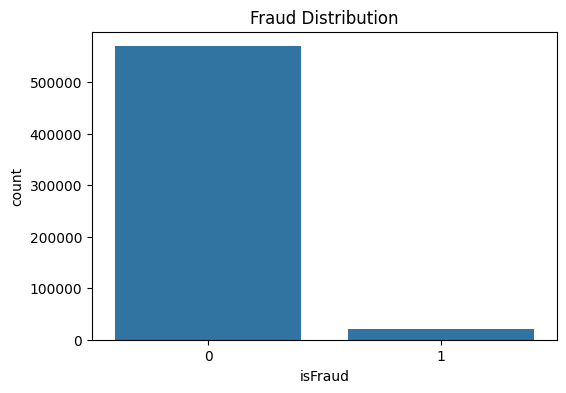

In [33]:
plt.figure(figsize=(6,4))
sns.countplot(
    data=encrypted_df,
    x="isFraud"
)
plt.title("Fraud Distribution")
plt.show()

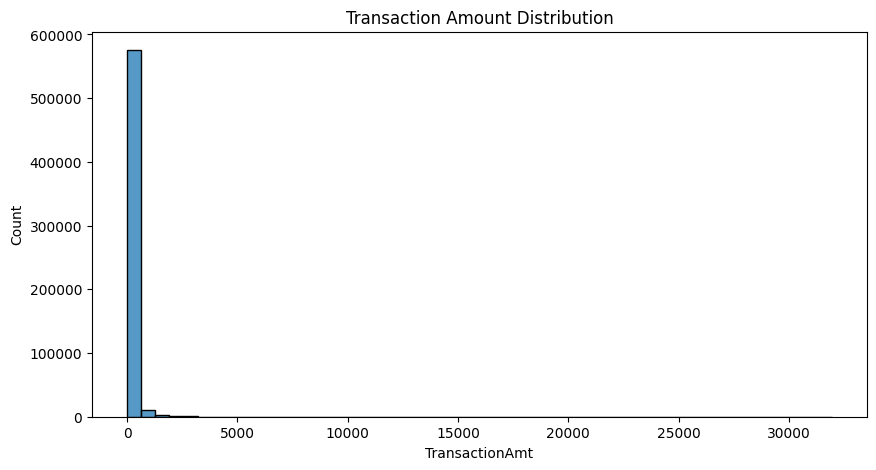

In [34]:
plt.figure(figsize=(10,5))
sns.histplot(
    encrypted_df["TransactionAmt"],
    bins=50
)
plt.title("Transaction Amount Distribution")
plt.show()

In [37]:
print(encrypted_df.columns)

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'id_37', 'id_38', 'DeviceType', 'DeviceInfo', 'CustomerName', 'Email',
       'PhoneNumber', 'Address', 'NationalID', 'CreditCardNumber'],
      dtype='str', length=428)


In [38]:
print("dist1" in encrypted_df.columns)
print("dist2" in encrypted_df.columns)

True
False


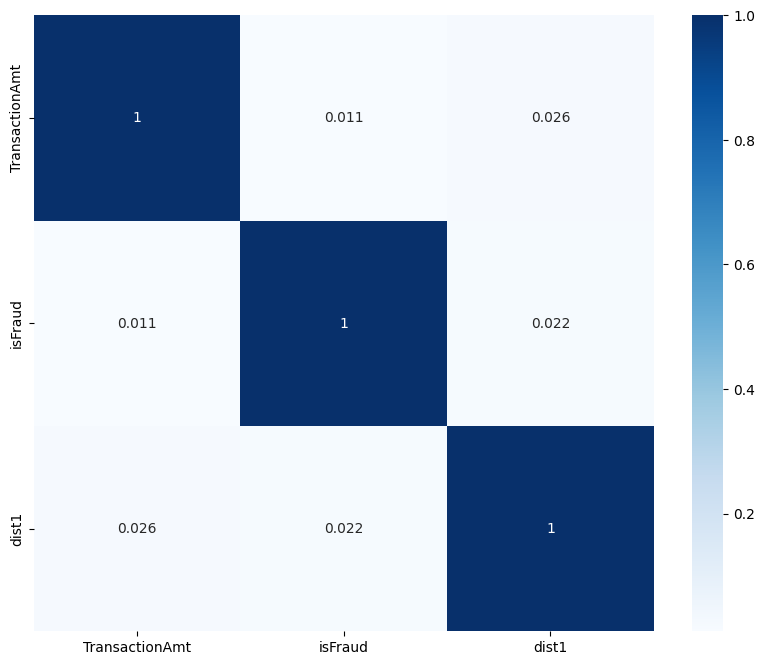

In [ ]:
corr_columns = ["TransactionAmt", "isFraud"]
if "dist1" in encrypted_df.columns:
    corr_columns.append("dist1")
if "dist2" in encrypted_df.columns:
    corr_columns.append("dist2")

corr = encrypted_df[corr_columns].corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr,
            annot=True,
            cmap="Blues")
plt.show()

In [44]:
lineage = {
    "Raw Dataset":
        "train_transaction.csv + train_identity.csv",
    "Merged Dataset":
        "Merged on TransactionID",
    "Columns Removed":
        len(columns_to_drop),
    "PII Columns":
        columns_to_encrypt,
    "Encryption":
        "Fernet (AES-128)"
}
pd.DataFrame(
    lineage.items(),
    columns=["Step","Description"]
).to_csv(
    "reports/data_lineage.csv",
    index=False
)

In [45]:
dpia = pd.DataFrame({
    "Risk":[
        "PII exposure",
        "Unauthorized access",
        "Data leakage"
    ],
    "Mitigation":[
        "Encryption",
        "Access control",
        "Private storage"
    ]
})
dpia.to_csv(
    "reports/DPIA_Report.csv",
    index=False
)

In [46]:
roles = {
    "Data Security Engineer":
        ["Read","Encrypt","Write"],
    "ML Engineer":
        ["Read Encrypted Data"],
    "Compliance Officer":
        ["Read Reports"]
}
pd.DataFrame(
    roles.items(),
    columns=["Role","Permissions"]
).to_csv(
    "reports/access_control.csv",
    index=False
)

In [49]:
analyzer = AnalyzerEngine()
text = "My email is yara@gmail.com"
results = analyzer.analyze(
    text=text,
    entities=["EMAIL_ADDRESS"],
    language="en"
)
print(results)

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
[type: EMAIL_ADDRESS, start: 12, end: 26, score: 1.0]


In [51]:
cipher = Fernet(key)

In [ ]:
connection_string = ""
blob_service_client = BlobServiceClient.from_connection_string(
    connection_string
)
container_client = blob_service_client.get_container_client(
    "secure-data"
)
with open(
    "data/encrypted/encrypted_dataset.csv",
    "rb"
) as data:
    container_client.upload_blob(
        name="encrypted_dataset.csv",
        data=data,
        overwrite=True
    )
print("Dataset uploaded successfully!")

'connection_string = ""\nblob_service_client = BlobServiceClient.from_connection_string(\n    connection_string\n)\ncontainer_client = blob_service_client.get_container_client(\n    "secure-data"\n)\nwith open(\n    "data/encrypted/encrypted_dataset.csv",\n    "rb"\n) as data:\n    container_client.upload_blob(\n        name="encrypted_dataset.csv",\n        data=data,\n        overwrite=True\n    )\nprint("Dataset uploaded successfully!")'

In [54]:
key_management = pd.DataFrame({
    "Item":[
        "Encryption Key",
        "Storage Location",
        "Access"
    ],
    "Description":[
        "Fernet key",
        "Azure Key Vault",
        "Security Engineer only"
    ]
})

key_management.to_csv(
    "reports/key_management.csv",
    index=False
)

In [55]:
documentation = pd.DataFrame({
    "Step":[
        "Data Loading",
        "Classification",
        "Encryption",
        "Access Control",
        "Storage"
    ],
    "Description":[
        "Merged transaction and identity data",
        "Identified PII and sensitive columns",
        "Encrypted PII using Fernet",
        "Defined RBAC policies",
        "Stored encrypted dataset securely"
    ]
})

documentation.to_csv(
    "reports/security_preprocessing_docs.csv",
    index=False
)